In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns


**Question 1**

In [40]:
df = pd.read_csv("golub.csv")
df.head()

,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,48,BM,F,DFCI,BM:f,allB,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876


In [41]:
df["target"] = df["cancer"].replace({
    "allB": 0,
    "allT": 0,
    "aml": 1,
})
df

/var/folders/tz/xg7l_kjj7dzgywk9f7xth65m0000gn/T/ipykernel_24838/1327872856.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["target"] = df["cancer"].replace({


,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at,target
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,...,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092,0
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,...,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577,0
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,...,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231,0
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116,0
4,48,BM,F,DFCI,BM:f,allB,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,29,BM,NaN,CALGB,BM:NA,aml,-589.611534,-877.740714,-618.647808,-192.037937,...,475.796364,-502.502712,-4.418936,-652.151201,0.048183,-509.203391,-609.713570,4925.046956,-627.582046,1
68,30,BM,NaN,CALGB,BM:NA,aml,-1552.764727,-1288.774596,-1085.544097,-232.814069,...,657.628835,-754.508853,102.411495,-817.363646,657.628835,-410.902650,-905.360357,-109.199643,-951.453872,1
69,31,BM,NaN,CALGB,BM:NA,aml,-772.071972,-809.591203,-593.303872,-193.834414,...,605.104501,-575.647763,-226.939618,-750.001836,596.276447,95.284364,-758.829890,-407.914731,-772.071972,1
70,32,BM,NaN,CALGB,BM:NA,aml,-1124.873709,-1026.849847,-935.360908,-135.921851,...,1188.489447,-887.438131,88.443879,-859.120126,1693.856917,-236.124022,-769.809496,-205.627709,-861.298435,1


**Question 2**

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [43]:
meta_cols = ["Samples", "BM.PB", "Gender", "Source", "tissue.mf", "cancer", "target"]
gene_cols = [col for col in df.columns if col not in meta_cols]

X = df[gene_cols]
y = df["target"]

# fit linear regression
model = LinearRegression()
model.fit(X, y)

# predictions
y_pred = model.predict(X)

# residuals and MSE
residuals = y - y_pred
mse = mean_squared_error(y, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 3.5610016687287904e-30


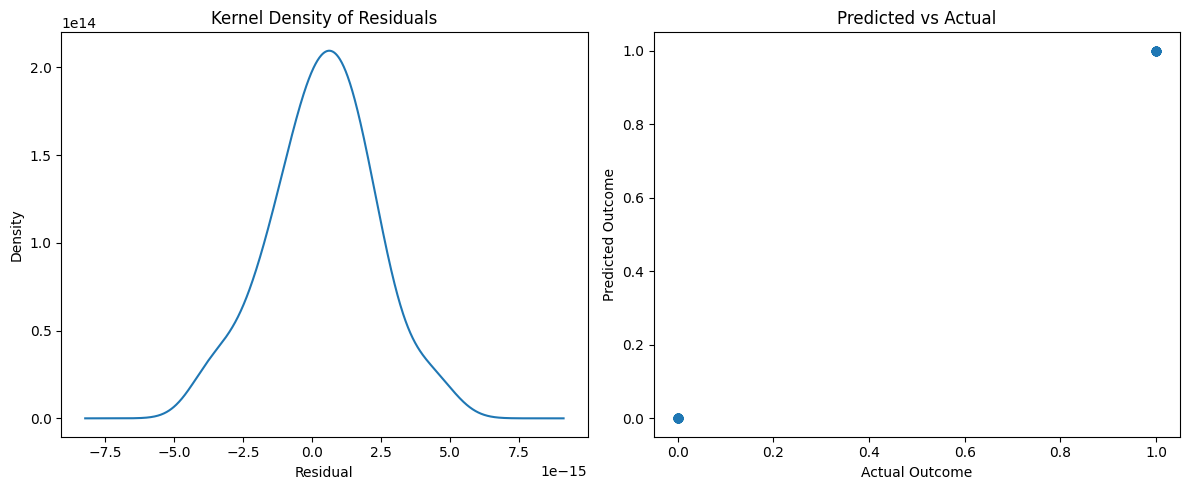

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# KDE plot of residuals
pd.Series(residuals).plot.kde(ax=axes[0])
axes[0].set_xlabel("Residual")
axes[0].set_title("Kernel Density of Residuals")

# Scatter plot of predicted vs actual
axes[1].scatter(y, y_pred, alpha=0.7)
axes[1].set_xlabel("Actual Outcome")
axes[1].set_ylabel("Predicted Outcome")
axes[1].set_title("Predicted vs Actual")

plt.tight_layout()
plt.show()

**Question 3**

In [45]:
from sklearn.model_selection import KFold, cross_val_score

In [50]:
meta_cols = ["Samples", "BM.PB", "Gender", "Source", "tissue.mf", "cancer", "target"]
gene_cols = [col for col in df.columns if col not in meta_cols]

X = df[gene_cols]
y = df["target"]

# linear model
model = LinearRegression()


kf = KFold(n_splits=10, shuffle=True, random_state=100)


cv_mse_scores = -cross_val_score(
    model,
    X,
    y,
    cv=kf,
    scoring="neg_mean_squared_error"
)

print("Cross-validated MSEs:", cv_mse_scores)
print("Mean CV MSE:", cv_mse_scores.mean())

Cross-validated MSEs: [0.02265367 0.04875751 0.06347474 0.06304086 0.09383082 0.08300696
 0.0207161  0.01969831 0.02087605 0.02271393]
Mean CV MSE: 0.04587689508852549


Compared to the MSE from part 2, which was basically 0, the cross-validated MSE is much higher. This suggests that the model fits the training data extremely well, but does not generalize as well to new data. Since the model uses all of the genes, it has enough flexibility to capture a lot of patterns, so the bias is low. At the same time, that flexibility seems to make the model too sensitive to the specific dataset, which means the variance is high. So overall, the model appears to be overfitting.

**Question 4**

In [ ]:
from sklearn.linear_model import LassoCV

mse = lambda y, yhat: np.sum((y-yhat)**2)/len(yhat)
z_score = lambda x: (x-x.mean())/x.std()



X = df.loc[:, gene_cols].apply(z_score)
y = df['target']


model = LassoCV(cv=10, random_state=100, max_iter=10000)
model.fit(X, y)


y_hat = model.predict(X)
print('Training MSE:', mse(y, y_hat))


coefs = pd.Series(model.coef_, index=gene_cols)
selected_genes = coefs[coefs != 0]
discarded_genes = coefs[coefs == 0]

print('\nSelected genes:')
print(selected_genes.sort_values())

print('\nNumber of selected genes:', len(selected_genes))
print('Number of discarded genes:', len(discarded_genes))
print('Chosen alpha:', model.alpha_)

Training MSE: 2.298941637525326e-05

Selected genes:
Y10207_at     -0.039755
M26708_s_at   -0.039473
X69111_at     -0.021136
U89942_at     -0.018703
M96843_at     -0.016409
                 ...   
M13690_s_at    0.038936
M22960_at      0.044730
M27891_at      0.061237
M31994_at      0.065844
M19507_at      0.115509
Length: 70, dtype: float64

Number of selected genes: 70
Number of discarded genes: 7059
Chosen alpha: 0.0011629872195690956


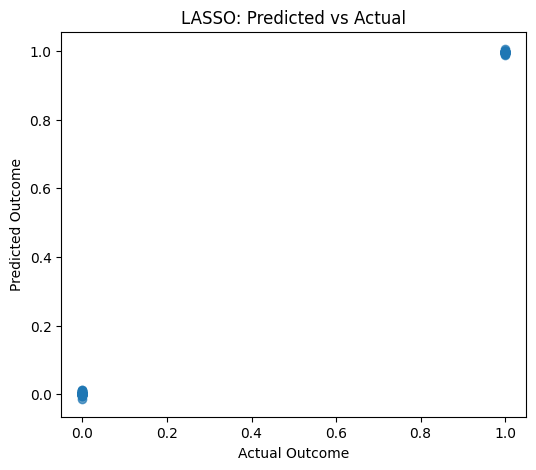

In [48]:
plt.figure(figsize=(6,5))
plt.scatter(y, y_hat, alpha=.7)
plt.xlabel('Actual Outcome')
plt.ylabel('Predicted Outcome')
plt.title('LASSO: Predicted vs Actual')
plt.show()

In [ ]:
**Question 5**

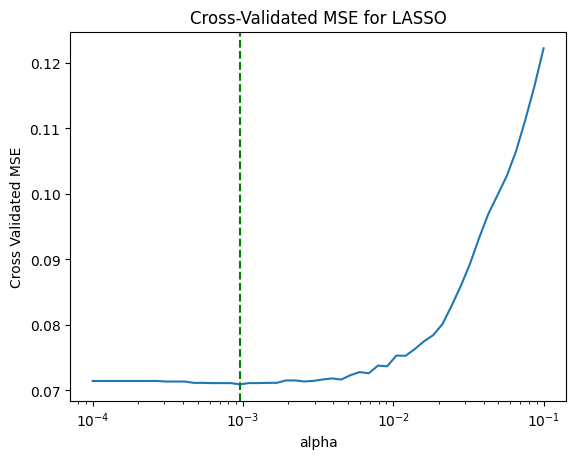

Optimal penalty hyperparameter: 0.0009540954763499944
Minimum cross-validated MSE: 0.07091365165568222


In [52]:
alpha_grid = np.logspace(-4, -1, num=50)

model = LassoCV(cv=10,
                alphas=alpha_grid,
                random_state=100,
                max_iter=10000)

model = model.fit(X, y)

mean_mse = np.mean(model.mse_path_, axis=1)
index_star = np.argmin(mean_mse)
alpha_star = model.alphas_[index_star]

sns.lineplot(x=model.alphas_, y=mean_mse)
plt.axvline(x=alpha_star, color='green', linestyle='--', linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross Validated MSE")
plt.title("Cross-Validated MSE for LASSO")
plt.show()

print("Optimal penalty hyperparameter:", alpha_star)
print("Minimum cross-validated MSE:", mean_mse[index_star])

At α≈0.000954,the cross-validated MSE is minimized. The minimum cross-validated MSE at this point is about 0.0709. For values of 𝛼 α smaller than this, the penalty is too weak, so the model keeps too many genes and is more likely to overfit. For values of 𝛼 α larger than this, the penalty becomes too strong, so the coefficients are shrunk too aggressively and the model is more likely to underfit.

**Question 6**

Linear regression performs perfectly on the training set because it uses all of the genes with no penalty, so it has enough flexibility to fit the sample almost exactly. 
However, this large amount of predictors relative to the number of observations makes the model also match the random noise in the training data. That is why its training MSE is essentially zero. 

The LASSO gives better predictions overall because it adds a penalty for large coefficients and shrinks many of them to zero. By doing this, it keeps only the genes that are most useful for prediction and reduces the influence of noisy variables. Genes with coefficients set to 0 are effectively excluded from the model. As a result, LASSO is less flexible and may not fit the training data perfectly, but it usually generalizes better to new data.

Sum: ordinary linear regression has extremely low bias but very high variance, while the LASSO accepts a little more bias in order to reduce variance. That trade-off leads to better out-of-sample prediction.

**Question 7**

Regularization methods work well in precision health because there are often way more variables, like genes or biomarkers, than patients. In that kind of high-dimensional data, models can easily overfit. Regularization helps by shrinking less useful variables, which makes predictions more stable on new patients and can also highlight the most important predictors.

**Question 8**

One risk is that LASSO might drop variables that are actually important but just look weak in one dataset, especially in health data where predictors can be correlated or if the dataset itself is biased in some way. This is concerning as a model could miss part of the real biology and lead to oversimplified decisions. Another risk is that even if the model predicts well statistically, using it for interventions is higher stakes, because mistakes could directly affect patient care, so over-trusting a selected set of predictors could be harmful.